# Hotel Booking Cancellation Analysis
## Project Overview
This project analyzes hotel booking data to understand the characteristics associated with booking cancellations.

In [1]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load the dataset
df = pd.read_csv('C:/Users/NEC/OneDrive/Documents/Python for Data analytics and Data apps/Hotel bookings analysis/data/hotel_bookings.csv')

In [3]:
# preview data
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [27]:
df.to_csv('cleaned_hotel_bookings.csv',index=False)

In [28]:
# shape of the dataframe
df.shape

(86944, 37)

Dataset has 119390 rows and 32 columns

In [29]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
Index: 86944 entries, 0 to 119389
Data columns (total 37 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           86944 non-null  str    
 1   is_canceled                     86944 non-null  int64  
 2   lead_time                       86944 non-null  int64  
 3   arrival_date_year               86944 non-null  int64  
 4   arrival_date_month              86944 non-null  str    
 5   arrival_date_week_number        86944 non-null  int64  
 6   arrival_date_day_of_month       86944 non-null  int64  
 7   stays_in_weekend_nights         86944 non-null  int64  
 8   stays_in_week_nights            86944 non-null  int64  
 9   adults                          86944 non-null  int64  
 10  children                        86944 non-null  float64
 11  babies                          86944 non-null  int64  
 12  meal                            86944 non-null 

In [30]:
# Check for missing values
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

## Data Cleaning

In [31]:
# fill company and agent with 0(indicating booked directly)
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)


In [32]:
# fill children column with 0(indicating no children)
df['children'] = df['children'].fillna(0)

In [33]:
# drop the rest of the missing values
df = df.dropna()

In [34]:
# drop duplicates
df = df.drop_duplicates()

In [35]:
# recheck the shape
df.shape

(86944, 37)

In [36]:
# recheck for missing values
df.isna().sum()


hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

In [37]:
# recheck for duplicates
df.duplicated().sum()

np.int64(0)

## Feature Engineering

In [38]:
# Calculate total nights 
df['total_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']

In [39]:
# Calculate total guests
df['total_guests'] = df['adults'] + df['children'] + df['babies']

In [40]:
# create 'is_family' (True if there are children or babies, False if otherwise)
df['is_family'] = (df['children']>0) | (df['babies']>0)

In [41]:
# create 'season' based on arrival month
month_to_season = {
    'December': 'Winter', 'January': 'Winter', 'February': 'Winter', 'March': 'Spring', 'April': 'Spring', 'May': 'Spring', 'June': 'Summer', 'July': 'Summer', 'August': 'Summer', 'September': 'Fall', 'October': 'Fall', 'November': 'Fall'
} 

df['season'] = df['arrival_date_month'].map(month_to_season)

In [42]:
# preview the data
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_nights,total_guests,is_family,season,is_canceled_label
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0.0,0,0,Check-Out,2015-07-01,0,2.0,False,Summer,Not Canceled
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0.0,0,0,Check-Out,2015-07-01,0,2.0,False,Summer,Not Canceled
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,75.0,0,0,Check-Out,2015-07-02,1,1.0,False,Summer,Not Canceled
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,75.0,0,0,Check-Out,2015-07-02,1,1.0,False,Summer,Not Canceled
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,98.0,0,1,Check-Out,2015-07-03,2,2.0,False,Summer,Not Canceled


## Exploratory Data Analysis (EDA)

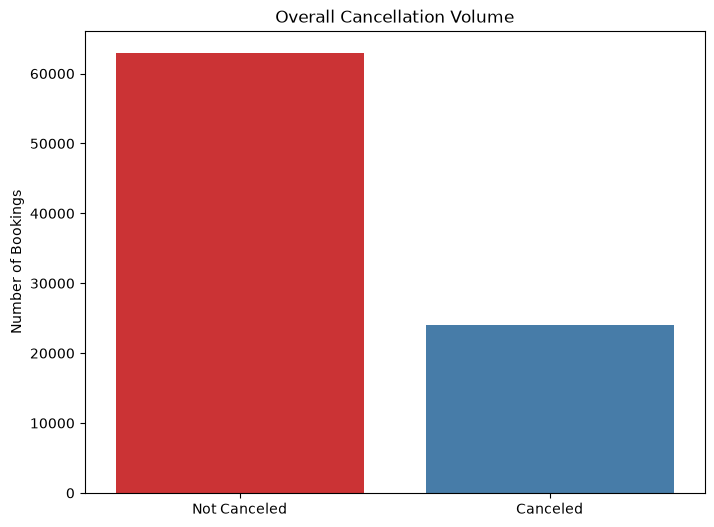

In [43]:
# What is the cancellation rate?
plt.figure(figsize=(8,6))
df['is_canceled_label'] = df['is_canceled'].map({0: 'Not Canceled', 1: 'Canceled'})
sns.countplot(data=df, x='is_canceled_label', hue='is_canceled_label', palette='Set1', legend=False)
plt.title('Overall Cancellation Volume')
plt.xlabel('')
plt.ylabel('Number of Bookings')
plt.savefig('Cancellation.png')
plt.show()

In [44]:
# calculate the cancellation rate
cancel_pct = df['is_canceled'].value_counts(normalize=True) * 100
print(f'Overall Cancellation Rate: {cancel_pct[1]:.1f}%')

Overall Cancellation Rate: 27.6%


The cancellation rate is 27.6% this means that 1 in 3 bookings is cancelled. Thus the hotel cannot rely on the initial booking numbers for staffing and food ordering. Management must utilize an overbooking strategy to ensure the hotel is full on a given night.

hotel         is_canceled
City Hotel    0              69.965557
              1              30.034443
Resort Hotel  0              76.296164
              1              23.703836
Name: proportion, dtype: float64

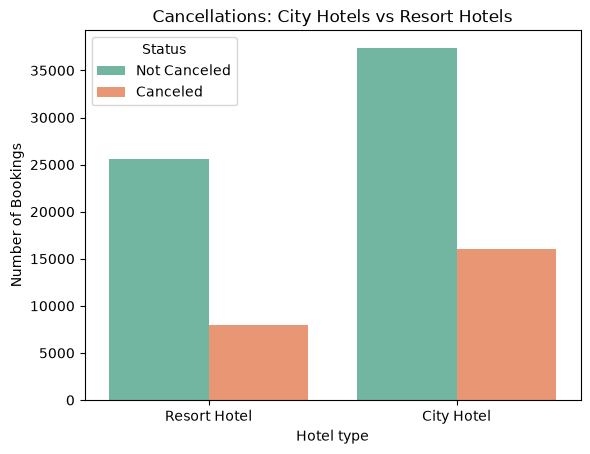

In [45]:
# Hotel Type Comparison
# Does hotel type affect the likelihood of cancellations? We will compare city hotels to resort hotelsto see if their customer bases behave differently
plt.Figure(figsize=(8,5))
sns.countplot(x='hotel', hue='is_canceled_label', data=df, palette='Set2')
plt.title('Cancellations: City Hotels vs Resort Hotels')
plt.ylabel('Number of Bookings')
plt.xlabel('Hotel type')
plt.legend(title='Status')
plt.savefig('hoteltype.png')
plt.show

# Calculate rates per hotel type
df.groupby('hotel')['is_canceled'].value_counts(normalize=True) * 100

City hotels see significantly higher booking volumes but they also suffer from a much higher cancellation rate compared to resort hotels. City trips are often short, impulsive or tried to business meetings that get moved. Resort trips are usually planned(often involving flights), making the guests less likely to abandon their plans.

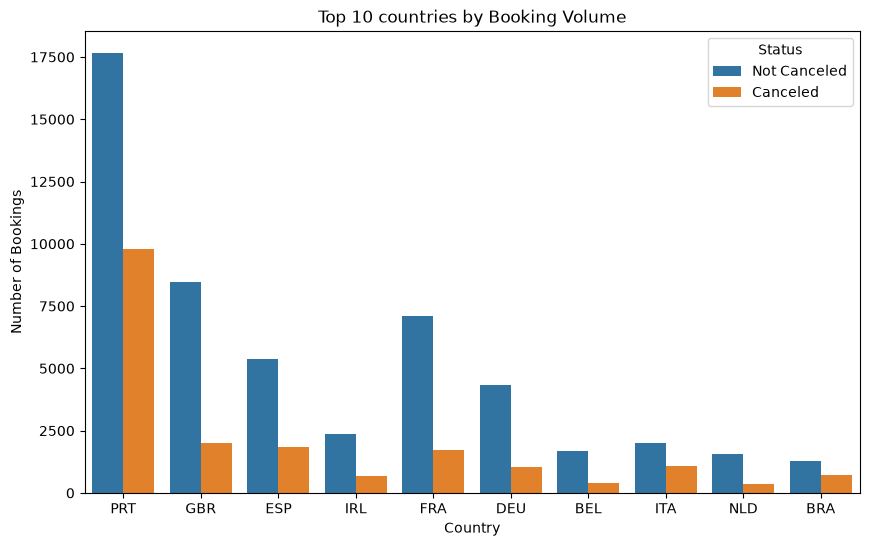

In [46]:
# Understanding the geographical origin of our customers Countries
plt.figure(figsize=(10,6))

# get the top 10 countries by volume
top_10_countries = df['country'].value_counts().head(10).index

sns.countplot(x='country', hue='is_canceled_label', data=df[df['country'].isin(top_10_countries)])

plt.title('Top 10 countries by Booking Volume')
plt.ylabel('Number of Bookings')
plt.xlabel('Country')
plt.legend(title='Status')
plt.savefig('Countries.png')
plt.show()

PRT(Portugal) generated the highest booking volume, but it also has a staggering cancellation rate. Because the hotels in this dataset are from portugal, the guests are local residents. Locals often book multiple hotels as 'backups' for weekend getaways because they don't have to commit to flights.

International guests rarely cancel because bookings are locked in by airline tickets

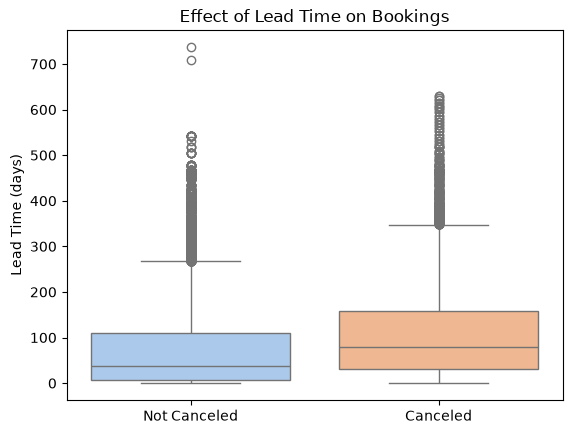

In [47]:
# Lead Time Analysis - Leadtime is the number of days between when the guest books and when they arrive
# Does booking in advance make the guest likely to cancel?

plt.Figure(figsize=(8,5))
sns.boxplot(x='is_canceled_label', y='lead_time', data = df, hue='is_canceled_label', palette='pastel', legend=False)

plt.title('Effect of Lead Time on Bookings')
plt.ylabel('Lead Time (days)')
plt.xlabel('')
plt.savefig('leadtime.png')
plt.show()



The boxplot shows that the median lead time for cancelled bookings is much higher. Simply put: the earlier someone books the more time they have to change their mind.

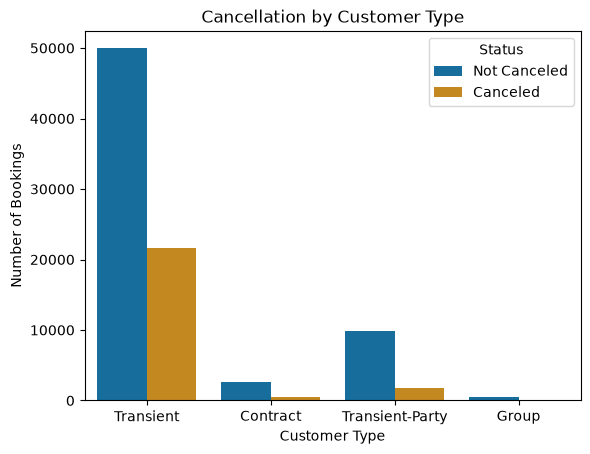

In [48]:
# Customer Type Analysis
# Are solo/transient travellers more volatile than large groups or corporate contracts?

plt.Figure(figsize=(8,5))
sns.countplot(x='customer_type', hue='is_canceled_label', data = df, palette='colorblind')
plt.title('Cancellation by Customer Type')
plt.ylabel('Number of Bookings')
plt.xlabel('Customer Type')
plt.legend(title='Status')
plt.savefig('customer.png')
plt.show() 

'Transient' travellers(Independent traveller not part of a group) account for the vast majority of both bookings and cancellations. Conversely, 'Groups' and 'Contract' bookings are much more stable.
Recommendation:
The sales team should prioritize securing more B2B contracts and groups events to build stable, guaranteed revenue base that protects against volatility of individual travellers

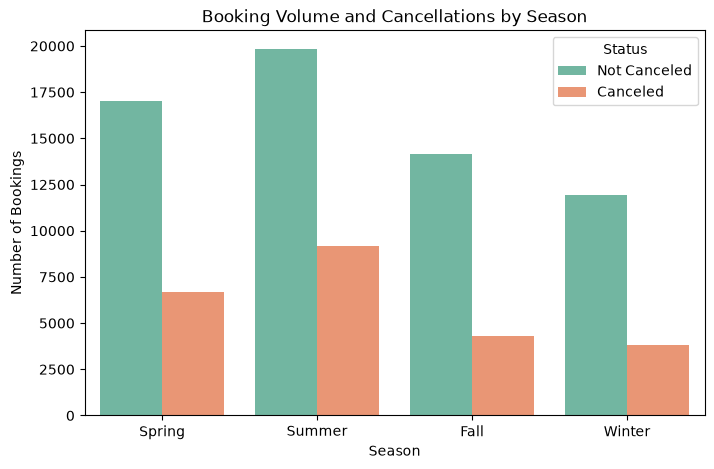

season  is_canceled
Fall    0              76.62
Winter  0              75.74
Spring  0              71.80
Summer  0              68.40
        1              31.60
Spring  1              28.20
Winter  1              24.26
Fall    1              23.38
Name: proportion, dtype: float64

In [49]:
# Seasonal Cancellation Analysis
plt.figure(figsize=(8,5))

# Logical flow of seasons
season_order = ['Spring', 'Summer', 'Fall', 'Winter']

sns.countplot(x='season', hue='is_canceled_label', data = df, order=season_order, palette='Set2')

plt.title('Booking Volume and Cancellations by Season')
plt.ylabel('Number of Bookings')
plt.xlabel('Season')
plt.legend(title='Status')
plt.savefig('seasonal.png')
plt.show()

# Calculate the cancellation rate per season
season_cancel_rate = df.groupby('season')['is_canceled'].value_counts(normalize=True) * 100
season_cancel_rate.round(2).sort_values(ascending=False)

Summer shows the highest total volume of bookings and highest absolute number of cancellations


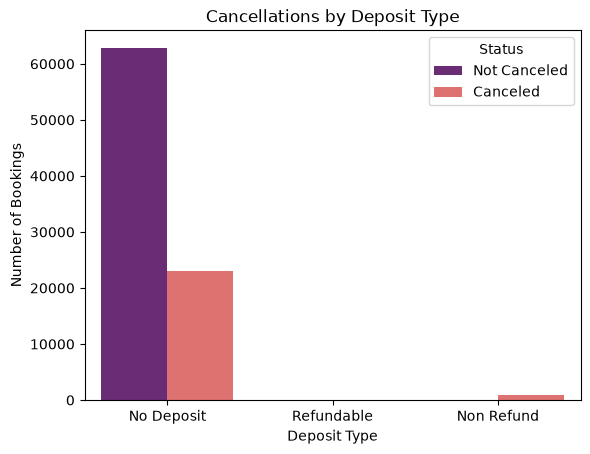

In [50]:
# Impact of deposit type on cancellations
plt.Figure(figsize=(8,5))
sns.countplot(x='deposit_type', hue='is_canceled_label', data=df, palette='magma')
plt.title('Cancellations by Deposit Type')
plt.ylabel('Number of Bookings')
plt.xlabel('Deposit Type')
plt.legend(title='Status')
plt.savefig('deposittype.png')
plt.show()

Majority of the bookings require no deposits. Our recommendation is to make the deposit compulsory and non-refundable. 